In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Time per output token (ms per token) = time(s) / num output tokens * 1000
eager_tpot = 1000 * 1050.20 / 97414
eager_always_exit_tpot = 1000 * 1350.73 / 125000
eager_no_lm_no_copy_always_exit_tpot = 1000 * 1145.20 / 125000
eager_no_lm_always_exit = 1000 * 1335.37 / 125000
eager_no_copy_always_exit = 1000 * 1155.40 / 125000
rebatching_tpot = 1000 * 1329.87 / 102194
off_tpot = 1000 * 1010.13 / 101748

In [16]:
lm_cost = eager_always_exit_tpot - eager_no_lm_always_exit
copy_cost = eager_always_exit_tpot - eager_no_copy_always_exit
lm_cost, copy_cost, off_tpot

(0.12288000000000032, 1.56264, 9.927762707866494)

<Figure size 640x480 with 0 Axes>

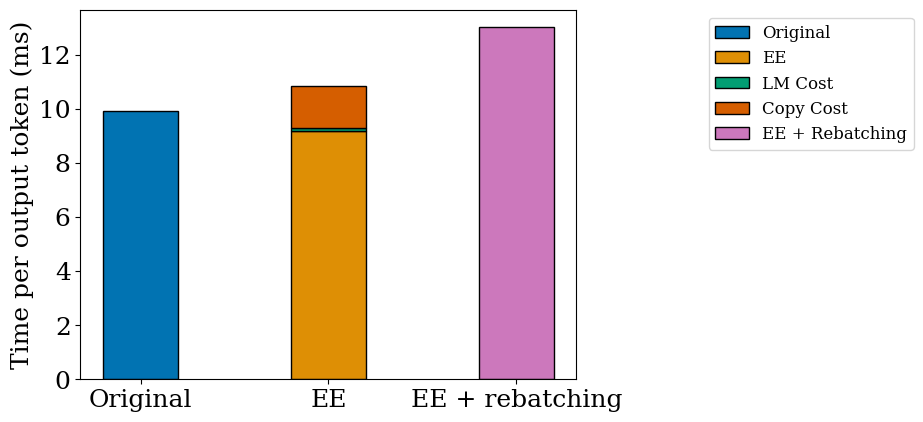

In [21]:
plt.style.use("seaborn-v0_8-deep")
plt.rc("font", size=18, family="serif")
plt.clf()
x_axis = ['Original', 'EE', 'EE + rebatching']
x_values = np.arange(len(x_axis))
with sns.color_palette("colorblind"):
    fig, ax = plt.subplots()
    original_bar = ax.bar(x_values[0], off_tpot, width=0.4, edgecolor="k", label="Original")
    ee_bar = ax.bar(x_values[1], eager_no_lm_no_copy_always_exit_tpot, width=0.4, edgecolor="k", label="EE")
    lm_cost_bar = ax.bar(
        x_values[1],
        lm_cost,
        bottom=eager_no_lm_no_copy_always_exit_tpot,
        width=0.4,
        edgecolor="k",
        label="LM Cost",
    )
    copy_cost_bar = ax.bar(
        x_values[1],
        copy_cost,
        bottom=lm_cost + eager_no_lm_no_copy_always_exit_tpot,
        width=0.4,
        edgecolor="k",
        label="Copy Cost",
    )
    rebatching_bar = ax.bar(
        x_values[2],
        rebatching_tpot,
        width=0.4,
        edgecolor="k",
        label="EE + Rebatching",
    )
    ax.set_ylabel("Time per output token (ms)")
    ax.set_xticks(x_values, x_axis)
    ax.legend(
        handles=[original_bar, ee_bar, lm_cost_bar, copy_cost_bar, rebatching_bar],
        loc="upper left",
        bbox_to_anchor=(1.25, 1),
        fontsize=12,
    )
    plt.show()